Starting Model Consistency Analysis...
Analyzing folder: ../outputs
--------------------------------------------------
OSS -> OSS: 0.774 (72/93)
OpenT -> OpenT: 0.659 (56/85)
OSS -> OpenT: 0.653 (62/95)
QwQ -> OpenT: 0.731 (68/93)
NRR -> OSS: 0.333 (27/81)
OSS -> DAPO: 0.582 (53/91)
OpenT -> OSS: 0.537 (44/82)
NRR -> DAPO: 0.216 (19/88)
OpenT -> DAPO: 0.536 (45/84)
OSS -> NRR: 0.435 (40/92)
QwQ -> OSS: 0.721 (62/86)
OSS -> QwQ: 0.699 (65/93)
QwQ -> DAPO: 0.761 (70/92)
NRR -> NRR: 0.622 (56/90)
OpenT -> NRR: 0.442 (38/86)
NRR -> QwQ: 0.286 (26/91)
OpenT -> QwQ: 0.500 (42/84)
QwQ -> NRR: 0.522 (47/90)
QwQ -> QwQ: 0.811 (73/90)
DAPO -> OSS: 0.713 (62/87)
DAPO -> DAPO: 0.891 (82/92)
DAPO -> NRR: 0.489 (43/88)
DAPO -> QwQ: 0.710 (66/93)
DAPO -> OpenT: 0.648 (59/91)
NRR -> OpenT: 0.455 (40/88)

Found 25 model pair combinations
--------------------------------------------------
Generating plots...
  Creating consistency heatmap...


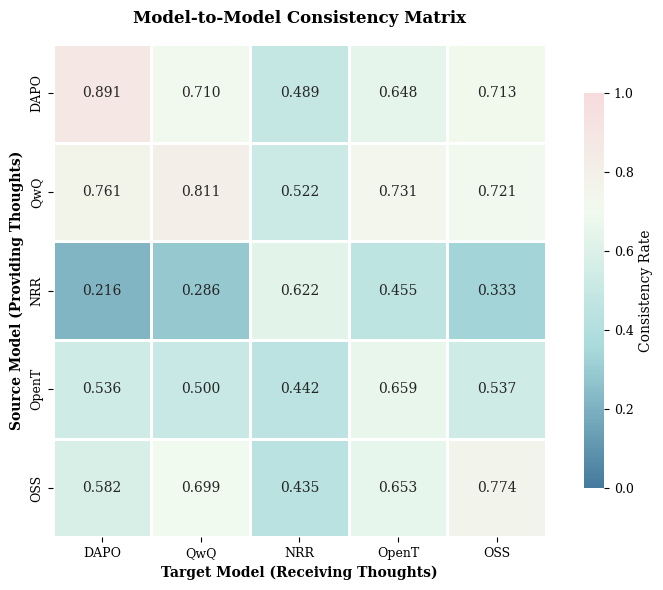

  Creating model comparison plot...


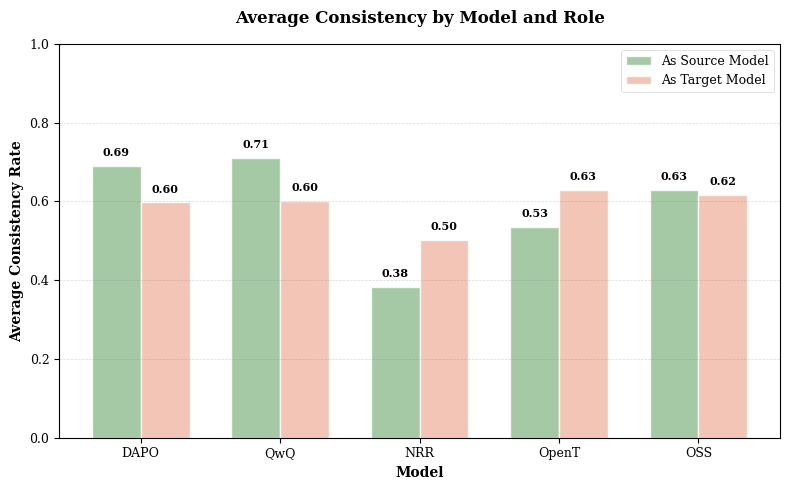

  Calculating pairwise consistency...
  Creating pairwise analysis plots...


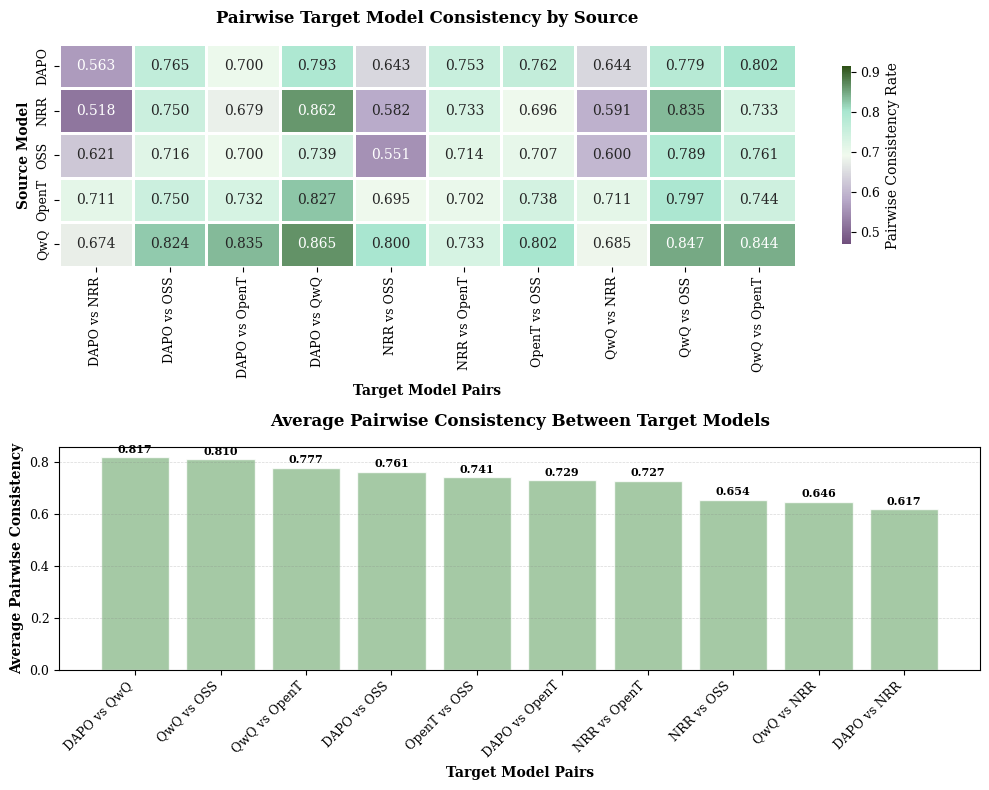


PAIRWISE TARGET MODEL CONSISTENCY
DAPO: DAPO vs OSS = 0.765 (65/85)
DAPO: NRR vs OSS = 0.643 (54/84)
DAPO: OSS vs QwQ = 0.779 (67/86)
DAPO: OSS vs OpenT = 0.762 (64/84)
DAPO: DAPO vs NRR = 0.563 (49/87)
DAPO: DAPO vs QwQ = 0.793 (73/92)
DAPO: DAPO vs OpenT = 0.700 (63/90)
DAPO: NRR vs QwQ = 0.644 (56/87)
DAPO: NRR vs OpenT = 0.753 (64/85)
DAPO: OpenT vs QwQ = 0.802 (73/91)
QwQ: OSS vs OpenT = 0.802 (69/86)
QwQ: DAPO vs OpenT = 0.835 (76/91)
QwQ: NRR vs OpenT = 0.733 (66/90)
QwQ: OpenT vs QwQ = 0.844 (76/90)
QwQ: DAPO vs OSS = 0.824 (70/85)
QwQ: NRR vs OSS = 0.800 (68/85)
QwQ: OSS vs QwQ = 0.847 (72/85)
QwQ: DAPO vs NRR = 0.674 (60/89)
QwQ: DAPO vs QwQ = 0.865 (77/89)
QwQ: NRR vs QwQ = 0.685 (61/89)
NRR: DAPO vs OSS = 0.750 (57/76)
NRR: NRR vs OSS = 0.582 (46/79)
NRR: OSS vs QwQ = 0.835 (66/79)
NRR: OSS vs OpenT = 0.696 (55/79)
NRR: DAPO vs NRR = 0.518 (44/85)
NRR: DAPO vs QwQ = 0.862 (75/87)
NRR: DAPO vs OpenT = 0.679 (57/84)
NRR: NRR vs QwQ = 0.591 (52/88)
NRR: NRR vs OpenT = 0.733 (

In [31]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for clean plots
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 100,
})

# Define pastel, paper-friendly color schemes
HEATMAP_COLORS = ['#457B9D', '#A8DADC', '#F1FAEE', '#F8D7DA', '#E63946']
HEATMAP_CMAP = LinearSegmentedColormap.from_list('pastel_heatmap', HEATMAP_COLORS)

PAIRWISE_COLORS = ['#6F4E7C', '#B8A9C9', '#F1FAEE', '#A8E6CF', '#2D5016']
PAIRWISE_CMAP = LinearSegmentedColormap.from_list('pastel_pairwise', PAIRWISE_COLORS)

BAR_COLORS = ['#8FBC8F', '#F0B7A4']  # Soft green and soft peach

def create_short_model_names():
    """Create mapping for short model names."""
    return {
        'openai_gpt-oss-20b': 'OSS',
        'BytedTsinghua-SIA_DAPO-Qwen-32B': 'DAPO', 
        'Qwen_QwQ-32B': 'QwQ',
        'open-thoughts_OpenThinker-7B': 'OpenT',
        'nvidia_Nemotron-Research-Reasoning-Qwen-1.5B': 'NRR'
    }

def parse_jsonl_file(filepath):
    """Parse a JSONL file and return list of data points."""
    data_points = []
    
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if line:
                    try:
                        data = json.loads(line)
                        data_points.append(data)
                    except json.JSONDecodeError as e:
                        print(f"Error parsing line {line_num} in {filepath}: {e}")
                        continue
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return []
    except Exception as e:
        print(f"Error reading file {filepath}: {e}")
        return []
    
    return data_points

def check_consistency(data_point):
    """Check if two models are consistent on a data point."""
    llm_answer = data_point.get("LLM Answer", "")
    target_answer = data_point.get("Target Answer", "")

    # Skip invalid responses
    invalid_patterns = ["not defined", "N/A", "does not match", "are not permitted"]
    if any(pattern in llm_answer for pattern in invalid_patterns) or \
       any(pattern in target_answer for pattern in invalid_patterns):
        return None
    
    # Exact match
    if llm_answer == target_answer:
        return 1
    
    # Both results are "Correct"
    result = data_point.get("Result", "")
    target_result = data_point.get("Target Result", "")
    if result == "Correct" and target_result == "Correct":
        return 1
    
    return 0

def extract_model_names(filename):
    """Extract source and target model names from filename."""
    pattern = r'(.+)_thoughts_to_(.+)_zero_shot_'
    match = re.match(pattern, filename)
    return (match.group(1), match.group(2)) if match else (None, None)

def calculate_consistency_matrix(folder_path):
    """Calculate consistency matrix for all model pairs."""
    if not os.path.exists(folder_path):
        print(f"Folder path does not exist: {folder_path}")
        return {}, [], {}
    
    consistency_data = {}
    model_names = set()
    data_by_source = {}
    
    jsonl_files = [f for f in os.listdir(folder_path) if f.endswith('.jsonl') and '_thoughts_to_' in f and 'without_answer' in f]
    
    if not jsonl_files:
        print("No JSONL files found matching the expected pattern.")
        return {}, [], {}
    
    for filename in jsonl_files:
        source_model, target_model = extract_model_names(filename)
        
        if source_model and target_model:
            model_names.add(source_model)
            model_names.add(target_model)
            
            filepath = os.path.join(folder_path, filename)
            data_points = parse_jsonl_file(filepath)
            
            if data_points:
                data_by_source[(source_model, target_model)] = data_points
                
                consistency_results = [check_consistency(dp) for dp in data_points]
                valid_results = [result for result in consistency_results if result is not None]
                
                if valid_results:
                    consistent_count = sum(valid_results)
                    total_count = len(valid_results)
                    consistency_rate = consistent_count / total_count
                    
                    consistency_data[(source_model, target_model)] = {
                        'consistency_rate': consistency_rate,
                        'consistent_count': consistent_count,
                        'total_count': total_count
                    }
                    
                    name_mapping = create_short_model_names()
                    short_source = name_mapping.get(source_model, source_model[:10])
                    short_target = name_mapping.get(target_model, target_model[:10])
                    print(f"{short_source} -> {short_target}: {consistency_rate:.3f} ({consistent_count}/{total_count})")
    
    return consistency_data, sorted(list(model_names)), data_by_source

def create_consistency_matrix(consistency_data, model_names):
    """Create a matrix for visualization."""
    n_models = len(model_names)
    matrix = np.zeros((n_models, n_models))
    model_to_idx = {model: idx for idx, model in enumerate(model_names)}
    
    for (source, target), data in consistency_data.items():
        if source in model_to_idx and target in model_to_idx:
            i = model_to_idx[source]
            j = model_to_idx[target]
            matrix[i, j] = data['consistency_rate']
    
    return matrix

def calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source):
    """Calculate pairwise consistency between target models for each source model."""
    pairwise_consistency = {}
    
    for source_model in model_names:
        targets = [target for (src, target) in consistency_data.keys() if src == source_model]
        
        if len(targets) < 2:
            continue
            
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                target_a = targets[i]
                target_b = targets[j]
                
                key_a = (source_model, target_a)
                key_b = (source_model, target_b)
                
                if key_a in data_by_source and key_b in data_by_source:
                    data_a = data_by_source[key_a]
                    data_b = data_by_source[key_b]
                    
                    consistent_pairs = 0
                    total_pairs = 0
                    
                    for idx in range(min(len(data_a), len(data_b))):
                        consistency_a = check_consistency(data_a[idx])
                        consistency_b = check_consistency(data_b[idx])
                        
                        if consistency_a is None or consistency_b is None:
                            continue
                        
                        total_pairs += 1
                        if consistency_a == consistency_b:
                            consistent_pairs += 1
                    
                    if total_pairs > 0:
                        pairwise_rate = consistent_pairs / total_pairs
                        pairwise_consistency[(source_model, target_a, target_b)] = {
                            'consistency_rate': pairwise_rate,
                            'consistent_pairs': consistent_pairs,
                            'total_pairs': total_pairs
                        }
    
    return pairwise_consistency

def plot_consistency_heatmap(consistency_data, model_names, save_plots=False, pdf_pages=None):
    """Create heatmap of consistency matrix."""
    fig, ax = plt.subplots(figsize=(8, 6))
    consistency_matrix = create_consistency_matrix(consistency_data, model_names)
    
    name_mapping = create_short_model_names()
    short_names = [name_mapping.get(name, name[:10]) for name in model_names]
    
    mask = consistency_matrix == 0
    sns.heatmap(consistency_matrix, 
                xticklabels=short_names, 
                yticklabels=short_names,
                annot=True, 
                fmt='.3f', 
                cmap=HEATMAP_CMAP,
                center=0.7,
                vmin=0.0, vmax=1.0,
                square=True,
                mask=mask,
                cbar_kws={'label': 'Consistency Rate', 'shrink': 0.8},
                linewidths=0.8,
                linecolor='white',
                ax=ax)
    
    ax.set_title('Model-to-Model Consistency Matrix', fontweight='bold', pad=15)
    ax.set_xlabel('Target Model (Receiving Thoughts)', fontweight='bold')
    ax.set_ylabel('Source Model (Providing Thoughts)', fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('consistency_heatmap.pdf', bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return consistency_matrix

def plot_model_comparison(consistency_data, model_names, save_plots=False, pdf_pages=None):
    """Create bar plot of average consistency by model."""
    fig, ax = plt.subplots(figsize=(8, 5))
    
    name_mapping = create_short_model_names()
    short_names = [name_mapping.get(name, name[:10]) for name in model_names]
    
    source_avg = defaultdict(list)
    target_avg = defaultdict(list)
    
    for (source, target), data in consistency_data.items():
        source_avg[source].append(data['consistency_rate'])
        target_avg[target].append(data['consistency_rate'])
    
    x = np.arange(len(model_names))
    width = 0.35
    
    source_values = [np.mean(source_avg[model]) if model in source_avg else 0 for model in model_names]
    target_values = [np.mean(target_avg[model]) if model in target_avg else 0 for model in model_names]
    
    bars1 = ax.bar(x - width/2, source_values, width, label='As Source Model', 
                   color=BAR_COLORS[0], alpha=0.8, edgecolor='white', linewidth=1)
    bars2 = ax.bar(x + width/2, target_values, width, label='As Target Model', 
                   color=BAR_COLORS[1], alpha=0.8, edgecolor='white', linewidth=1)
    
    ax.set_xlabel('Model', fontweight='bold')
    ax.set_ylabel('Average Consistency Rate', fontweight='bold')
    ax.set_title('Average Consistency by Model and Role', fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names)
    ax.legend(frameon=True, fancybox=True, shadow=False, facecolor='white')
    ax.grid(axis='y', alpha=0.3, linestyle='--', color='gray')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_by_model.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('consistency_by_model.pdf', bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_pairwise_analysis(pairwise_consistency, save_plots=False, pdf_pages=None):
    """Create pairwise target model consistency visualizations."""
    if not pairwise_consistency:
        print("No pairwise consistency data available for visualization.")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    name_mapping = create_short_model_names()
    
    # Prepare data with short names
    target_pairs = []
    source_models = []
    pairwise_values = []
    
    for (source, target_a, target_b), data in pairwise_consistency.items():
        # Standardize pair names by sorting
        sorted_targets = sorted([target_a, target_b])
        short_a = name_mapping.get(sorted_targets[0], sorted_targets[0][:10])
        short_b = name_mapping.get(sorted_targets[1], sorted_targets[1][:10])
        pair_name = f"{short_a} vs {short_b}"
        
        target_pairs.append(pair_name)
        source_models.append(name_mapping.get(source, source[:10]))
        pairwise_values.append(data['consistency_rate'])
    
    pairwise_df = pd.DataFrame({
        'Source': source_models,
        'Target_Pair': target_pairs,
        'Consistency': pairwise_values
    })
    
    # Heatmap
    pivot_df = pairwise_df.pivot(index='Source', columns='Target_Pair', values='Consistency')
    
    if not pivot_df.empty:
        min_val = max(0.3, pivot_df.min().min() - 0.05)
        max_val = min(1.0, pivot_df.max().max() + 0.05)
    else:
        min_val, max_val = 0.3, 1.0
    
    mask = pivot_df.isna()
    
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap=PAIRWISE_CMAP, 
               ax=axes[0], cbar_kws={'label': 'Pairwise Consistency Rate', 'shrink': 0.8},
               vmin=min_val, vmax=max_val, linewidths=0.8, linecolor='white',
               mask=mask, cbar=True)
    
    axes[0].set_title('Pairwise Target Model Consistency by Source', fontweight='bold', pad=15)
    axes[0].set_xlabel('Target Model Pairs', fontweight='bold')
    axes[0].set_ylabel('Source Model', fontweight='bold')
    
    # Bar plot
    avg_pairwise = pairwise_df.groupby('Target_Pair')['Consistency'].mean().sort_values(ascending=False)
    
    bars = axes[1].bar(range(len(avg_pairwise)), avg_pairwise.values, 
                       color=BAR_COLORS[0], alpha=0.8, edgecolor='white', linewidth=1)
    axes[1].set_xlabel('Target Model Pairs', fontweight='bold')
    axes[1].set_ylabel('Average Pairwise Consistency', fontweight='bold')
    axes[1].set_title('Average Pairwise Consistency Between Target Models', fontweight='bold', pad=15)
    axes[1].set_xticks(range(len(avg_pairwise)))
    axes[1].set_xticklabels(avg_pairwise.index, rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3, linestyle='--', color='gray')
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('pairwise_target_consistency.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig('pairwise_target_consistency.pdf', bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()

def print_summary_statistics(consistency_data, pairwise_consistency):
    """Print summary statistics with short model names."""
    name_mapping = create_short_model_names()
    
    print("\n" + "="*60)
    print("PAIRWISE TARGET MODEL CONSISTENCY")
    print("="*60)
    
    pairwise_values = []
    for (source, target_a, target_b), data in pairwise_consistency.items():
        short_source = name_mapping.get(source, source[:10])
        short_a = name_mapping.get(target_a, target_a[:10])
        short_b = name_mapping.get(target_b, target_b[:10])
        
        sorted_short_targets = sorted([short_a, short_b])
        
        print(f"{short_source}: {sorted_short_targets[0]} vs {sorted_short_targets[1]} = {data['consistency_rate']:.3f} "
              f"({data['consistent_pairs']}/{data['total_pairs']})")
        pairwise_values.append(data['consistency_rate'])
    
    if pairwise_values:
        print(f"\nPairwise Analysis Summary:")
        print(f"  Mean: {np.mean(pairwise_values):.3f}")
        print(f"  Median: {np.median(pairwise_values):.3f}")
        print(f"  Std Dev: {np.std(pairwise_values):.3f}")
    
    print("\n" + "="*60)
    print("OVERALL CONSISTENCY ANALYSIS SUMMARY")
    print("="*60)
    
    if consistency_data:
        all_rates = [data['consistency_rate'] for data in consistency_data.values()]
        print(f"Source-to-Target Statistics:")
        print(f"  Mean: {np.mean(all_rates):.3f}")
        print(f"  Median: {np.median(all_rates):.3f}")
        print(f"  Std Dev: {np.std(all_rates):.3f}")
        print(f"  Min: {np.min(all_rates):.3f}")
        print(f"  Max: {np.max(all_rates):.3f}")
        
        print(f"\nTotal Model Pairs: {len(consistency_data)}")
        
        unique_models = sorted(set([src for src, _ in consistency_data.keys()] + [tgt for _, tgt in consistency_data.keys()]))
        short_models = [name_mapping.get(model, model[:10]) for model in unique_models]
        print(f"Models: {', '.join(short_models)}")

def plot_consistency_results(consistency_data, model_names, data_by_source, save_plots=False, save_pdf=True):
    """Create comprehensive visualizations."""
    pdf_pages = None
    if save_pdf:
        pdf_pages = PdfPages('model_consistency_analysis.pdf')
    
    print("Generating plots...")
    
    # Main heatmap
    print("  Creating consistency heatmap...")
    consistency_matrix = plot_consistency_heatmap(consistency_data, model_names, save_plots, pdf_pages)
    
    # Model comparison
    print("  Creating model comparison plot...")
    plot_model_comparison(consistency_data, model_names, save_plots, pdf_pages)
    
    # Pairwise analysis
    print("  Calculating pairwise consistency...")
    pairwise_consistency = calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source)
    
    if pairwise_consistency:
        print("  Creating pairwise analysis plots...")
        plot_pairwise_analysis(pairwise_consistency, save_plots, pdf_pages)
    else:
        print("  No pairwise consistency data found.")
    
    # Print statistics
    print_summary_statistics(consistency_data, pairwise_consistency)
    
    if pdf_pages:
        pdf_pages.close()
        print(f"\n✓ All plots saved to: model_consistency_analysis.pdf")
    
    return consistency_matrix, pairwise_consistency

def main(folder_path):
    """Main function to run the consistency analysis."""
    print("Starting Model Consistency Analysis...")
    print(f"Analyzing folder: {folder_path}")
    print("-" * 50)
    
    consistency_data, model_names, data_by_source = calculate_consistency_matrix(folder_path)
    
    if not consistency_data:
        print("No valid JSONL files found with the expected naming pattern.")
        print("Expected pattern: {Model A}_thoughts_to_{Model B}_zero_shot_full.jsonl")
        return None
    
    print(f"\nFound {len(consistency_data)} model pair combinations")
    print("-" * 50)
    
    consistency_matrix, pairwise_data = plot_consistency_results(
        consistency_data, model_names, data_by_source, save_plots=True, save_pdf=True)
    
    return consistency_data, consistency_matrix, model_names, pairwise_data

if __name__ == "__main__":
    folder_path = "../outputs"
    
    results = main(folder_path)
    if results:
        consistency_data, matrix, models, pairwise_data = results
        print("\nAnalysis completed successfully!")
    else:
        print("Analysis failed - check folder path and file formats.")

Starting Comprehensive Llama Pairwise Consistency Analysis...
Analyzing folder: ../outputs
----------------------------------------------------------------------------------------------------

**Filtering for:**
  Source models: ['Llama3.2', 'MedCalc-GRPO']
  Target models: ['OSS', 'DAPO', 'QwQ', 'OpenT', 'NRR']
  Conditions: with_answer, without_answer

Llama3.2 -> NRR [with_answer]: 0.562 (50/89)
Llama3.2 -> OpenT [with_answer]: 0.742 (69/93)
Llama3.2 -> OSS [with_answer]: 0.261 (23/88)
Llama3.2 -> DAPO [with_answer]: 0.247 (21/85)
Llama3.2 -> QwQ [with_answer]: 0.432 (38/88)
MedCalc-GRPO -> NRR [with_answer]: 0.742 (72/97)
MedCalc-GRPO -> OpenT [with_answer]: 0.910 (91/100)
MedCalc-GRPO -> OSS [with_answer]: 0.571 (52/91)
MedCalc-GRPO -> DAPO [with_answer]: 0.432 (41/95)
MedCalc-GRPO -> QwQ [with_answer]: 0.608 (59/97)
Llama3.2 -> NRR [without_answer]: 0.250 (23/92)
Llama3.2 -> OpenT [without_answer]: 0.356 (32/90)
Llama3.2 -> DAPO [without_answer]: 0.220 (20/91)
Llama3.2 -> QwQ [wi

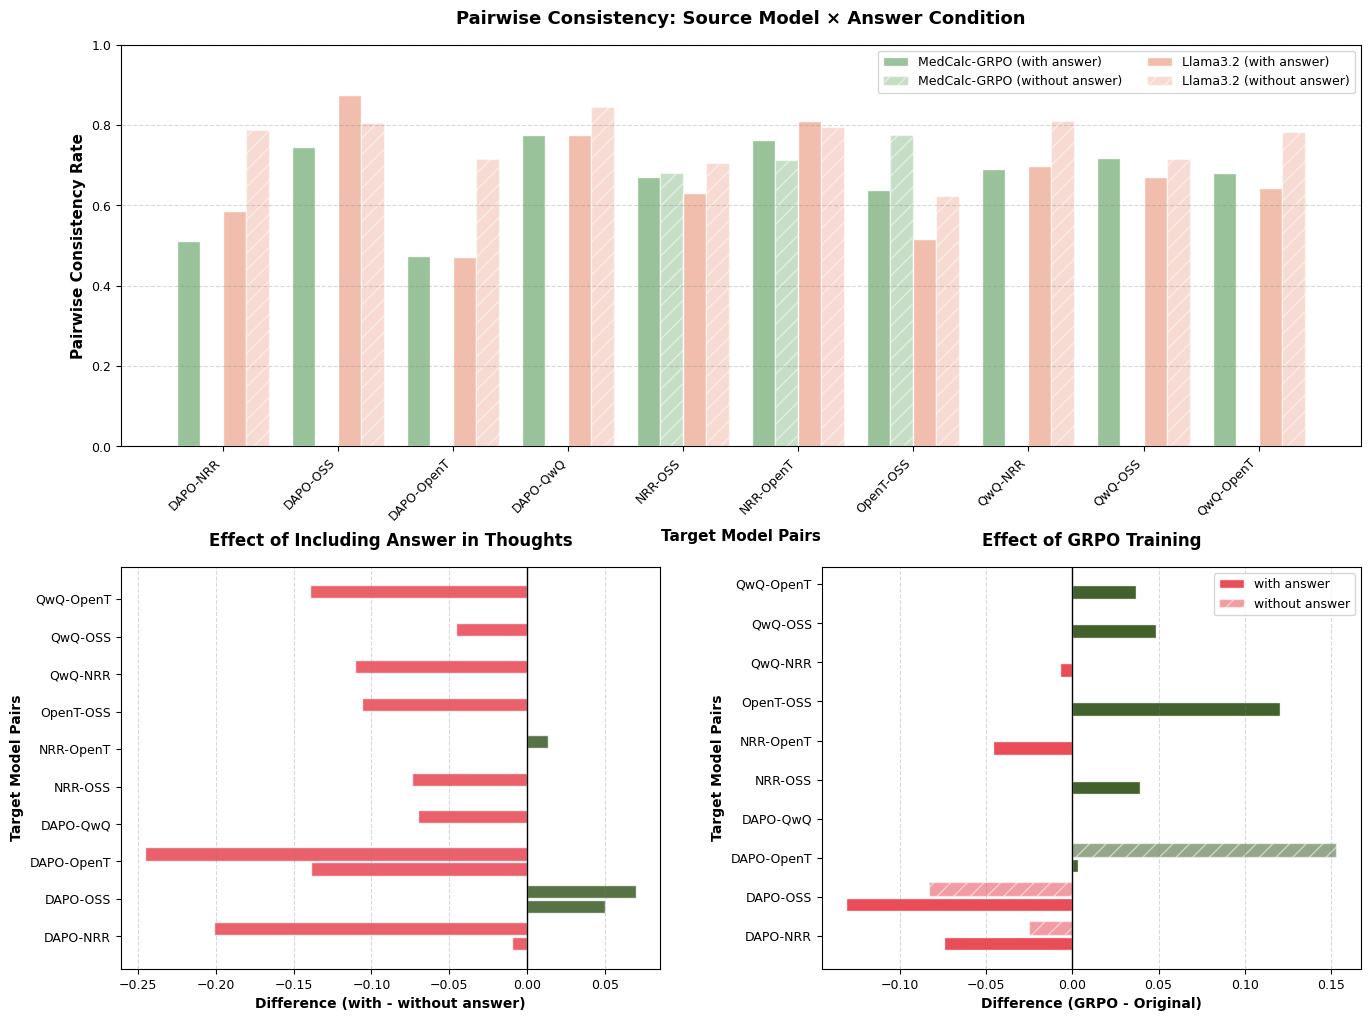


✓ All plots saved to: llama_comprehensive_analysis.pdf

COMPREHENSIVE PAIRWISE CONSISTENCY COMPARISON

WITH ANSWER
----------------------------------------------------------------------------------------------------
Target Pair                      MedCalc-GRPO            Llama3.2    Diff (GRPO-Orig)
----------------------------------------------------------------------------------------------------
DAPO vs NRR                             0.511               0.585              -0.074
DAPO vs OSS                             0.744               0.875              -0.131
DAPO vs OpenT                           0.474               0.471              +0.003
DAPO vs QwQ                             0.774               0.775              -0.001
NRR vs OSS                              0.670               0.631              +0.040
NRR vs OpenT                            0.763               0.809              -0.046
OpenT vs OSS                            0.637               0.517              +

In [6]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for clean plots
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 100,
})

# Define pastel, paper-friendly color schemes
HEATMAP_COLORS = ['#457B9D', '#A8DADC', '#F1FAEE', '#F8D7DA', '#E63946']
HEATMAP_CMAP = LinearSegmentedColormap.from_list('pastel_heatmap', HEATMAP_COLORS)

PAIRWISE_COLORS = ['#6F4E7C', '#B8A9C9', '#F1FAEE', '#A8E6CF', '#2D5016']
PAIRWISE_CMAP = LinearSegmentedColormap.from_list('pastel_pairwise', PAIRWISE_COLORS)

BAR_COLORS = ['#8FBC8F', '#F0B7A4', '#B8A9C9', '#A8E6CF']

# Define source and target models
SOURCE_MODELS = [
    'meta-llama_Llama-3.2-3B-Instruct',
    '_medcalc-llama-3-3b-inst-grpo'
]

TARGET_MODELS = [
    'openai_gpt-oss-20b',
    'BytedTsinghua-SIA_DAPO-Qwen-32B',
    'Qwen_QwQ-32B',
    'open-thoughts_OpenThinker-7B',
    'nvidia_Nemotron-Research-Reasoning-Qwen-1.5B'
]

def create_short_model_names():
    """Create mapping for short model names."""
    return {
        'openai_gpt-oss-20b': 'OSS',
        'BytedTsinghua-SIA_DAPO-Qwen-32B': 'DAPO', 
        'Qwen_QwQ-32B': 'QwQ',
        'open-thoughts_OpenThinker-7B': 'OpenT',
        'nvidia_Nemotron-Research-Reasoning-Qwen-1.5B': 'NRR',
        'meta-llama/Llama-3.2-3B-Instruct': 'Llama3.2',
        'meta-llama_Llama-3.2-3B-Instruct': 'Llama3.2',
        '_medcalc-llama-3-3b-inst-grpo': 'MedCalc-GRPO'
    }

def identify_model_types(sources):
    """Identify which model is GRPO and which is original."""
    grpo_model = None
    orig_model = None
    
    for source in sources:
        if 'grpo' in source.lower():
            grpo_model = source
        else:
            orig_model = source
    
    return grpo_model, orig_model

def parse_jsonl_file(filepath):
    """Parse a JSONL file and return list of data points."""
    data_points = []
    
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                    
                try:
                    data = json.loads(line)
                    data_points.append(data)
                except json.JSONDecodeError as e:
                    print(f"Error parsing line {line_num} in {filepath}: {e}")
    except FileNotFoundError:
        print(f"File not found: {filepath}")
    except Exception as e:
        print(f"Error reading file {filepath}: {e}")
    
    return data_points

def check_consistency(data_point):
    """Check if two models are consistent on a data point."""
    llm_answer = data_point.get("LLM Answer", "")
    target_answer = data_point.get("Target Answer", "")

    # Skip invalid responses
    invalid_patterns = ["not defined", "N/A", "does not match", "are not permitted"]
    if any(pattern in llm_answer for pattern in invalid_patterns) or \
       any(pattern in target_answer for pattern in invalid_patterns):
        return None
    
    # Exact match
    if llm_answer == target_answer:
        return 1
    
    # Both results are "Correct"
    result = data_point.get("Result", "")
    target_result = data_point.get("Target Result", "")
    if result == "Correct" and target_result == "Correct":
        return 1
    
    return 0

def extract_model_names_and_condition(filename):
    """Extract source, target model names and answer condition from filename."""
    pattern = r'(.+)_thoughts_to_(.+)_zero_shot'
    match = re.match(pattern, filename)
    
    if match:
        condition = "without" if "without_answer" in filename else "with"
        return match.group(1), match.group(2), condition
    
    return None, None, None

def calculate_consistency_matrix(folder_path, filter_source_models=None, filter_target_models=None):
    """Calculate consistency matrix for specified model pairs, separating by answer condition."""
    if not os.path.exists(folder_path):
        print(f"Folder path does not exist: {folder_path}")
        return {}, {}, [], {}
    
    consistency_data_with = {}
    consistency_data_without = {}
    model_names = set()
    data_by_source_with = {}
    data_by_source_without = {}
    
    jsonl_files = [f for f in os.listdir(folder_path) 
                   if f.endswith('.jsonl') and '_thoughts_to_' in f]
    
    if not jsonl_files:
        print("No JSONL files found matching the expected pattern.")
        return {}, {}, [], {}
    
    name_mapping = create_short_model_names()
    print(f"\n**Filtering for:**")
    print(f"  Source models: {[name_mapping.get(m, m) for m in filter_source_models]}")
    print(f"  Target models: {[name_mapping.get(m, m) for m in filter_target_models]}")
    print(f"  Conditions: with_answer, without_answer\n")
    
    for filename in jsonl_files:
        source_model, target_model, condition = extract_model_names_and_condition(filename)
        
        if not (source_model and target_model and condition):
            continue
            
        # Filter by source and target models
        if filter_source_models and source_model not in filter_source_models:
            continue
        if filter_target_models and target_model not in filter_target_models:
            continue
        
        model_names.add(source_model)
        model_names.add(target_model)
        
        filepath = os.path.join(folder_path, filename)
        data_points = parse_jsonl_file(filepath)
        
        if not data_points:
            continue
        
        # Store data based on condition
        consistency_data = consistency_data_with if condition == 'with' else consistency_data_without
        data_by_source = data_by_source_with if condition == 'with' else data_by_source_without
        
        data_by_source[(source_model, target_model)] = data_points
        
        consistency_results = [check_consistency(dp) for dp in data_points]
        valid_results = [result for result in consistency_results if result is not None]
        
        if valid_results:
            consistent_count = sum(valid_results)
            total_count = len(valid_results)
            consistency_rate = consistent_count / total_count
            
            consistency_data[(source_model, target_model)] = {
                'consistency_rate': consistency_rate,
                'consistent_count': consistent_count,
                'total_count': total_count
            }
            
            short_source = name_mapping.get(source_model, source_model[:10])
            short_target = name_mapping.get(target_model, target_model[:10])
            print(f"{short_source} -> {short_target} [{condition}_answer]: "
                  f"{consistency_rate:.3f} ({consistent_count}/{total_count})")
    
    return (consistency_data_with, consistency_data_without, sorted(list(model_names)), 
            {'with': data_by_source_with, 'without': data_by_source_without})

def calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source):
    """Calculate pairwise consistency between target models for each source model."""
    pairwise_consistency = {}
    
    for source_model in model_names:
        targets = [target for (src, target) in consistency_data.keys() if src == source_model]
        
        if len(targets) < 2:
            continue
            
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                target_a = targets[i]
                target_b = targets[j]
                
                key_a = (source_model, target_a)
                key_b = (source_model, target_b)
                
                if key_a not in data_by_source or key_b not in data_by_source:
                    continue
                
                data_a = data_by_source[key_a]
                data_b = data_by_source[key_b]
                
                consistent_pairs = 0
                total_pairs = 0
                
                for idx in range(min(len(data_a), len(data_b))):
                    consistency_a = check_consistency(data_a[idx])
                    consistency_b = check_consistency(data_b[idx])
                    
                    if consistency_a is None or consistency_b is None:
                        continue
                    
                    total_pairs += 1
                    if consistency_a == consistency_b:
                        consistent_pairs += 1
                
                if total_pairs > 0:
                    pairwise_rate = consistent_pairs / total_pairs
                    pairwise_consistency[(source_model, target_a, target_b)] = {
                        'consistency_rate': pairwise_rate,
                        'consistent_pairs': consistent_pairs,
                        'total_pairs': total_pairs
                    }
    
    return pairwise_consistency

def organize_pairwise_data(pairwise_data):
    """Organize pairwise data by source model with standardized pair names."""
    name_mapping = create_short_model_names()
    data_by_source = defaultdict(list)
    
    for (source, target_a, target_b), data in pairwise_data.items():
        sorted_targets = sorted([target_a, target_b])
        short_a = name_mapping.get(sorted_targets[0], sorted_targets[0][:10])
        short_b = name_mapping.get(sorted_targets[1], sorted_targets[1][:10])
        pair_name = f"{short_a}-{short_b}"
        
        data_by_source[source].append({
            'pair': pair_name,
            'consistency': data['consistency_rate'],
            'count': data['consistent_pairs'],
            'total': data['total_pairs']
        })
    
    return data_by_source

def plot_comprehensive_comparison(pairwise_with, pairwise_without, save_plots=False, pdf_pages=None):
    """Create comprehensive comparison across all dimensions."""
    name_mapping = create_short_model_names()
    
    data_with = organize_pairwise_data(pairwise_with)
    data_without = organize_pairwise_data(pairwise_without)
    
    # Get all unique pairs and sources
    all_pairs = set()
    for source_data in list(data_with.values()) + list(data_without.values()):
        for item in source_data:
            all_pairs.add(item['pair'])
    all_pairs = sorted(list(all_pairs))
    
    sources = sorted(set(list(data_with.keys()) + list(data_without.keys())))
    grpo_model, orig_model = identify_model_types(sources)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # Plot 1: Full comparison (source × condition)
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(all_pairs))
    width = 0.2
    
    for src_idx, source in enumerate(sources):
        short_source = name_mapping.get(source, source[:10])
        
        with_dict = {item['pair']: item['consistency'] for item in data_with.get(source, [])}
        without_dict = {item['pair']: item['consistency'] for item in data_without.get(source, [])}
        
        with_values = [with_dict.get(pair, 0) for pair in all_pairs]
        without_values = [without_dict.get(pair, 0) for pair in all_pairs]
        
        offset_with = (src_idx * 2 - 1.5) * width
        offset_without = (src_idx * 2 - 0.5) * width
        
        ax1.bar(x + offset_with, with_values, width, 
                label=f'{short_source} (with answer)', 
                color=BAR_COLORS[src_idx], alpha=0.9, 
                edgecolor='white', linewidth=1)
        ax1.bar(x + offset_without, without_values, width, 
                label=f'{short_source} (without answer)', 
                color=BAR_COLORS[src_idx], alpha=0.5, 
                edgecolor='white', linewidth=1, hatch='//')
    
    ax1.set_xlabel('Target Model Pairs', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Pairwise Consistency Rate', fontweight='bold', fontsize=11)
    ax1.set_title('Pairwise Consistency: Source Model × Answer Condition', 
                  fontweight='bold', pad=15, fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_pairs, rotation=45, ha='right')
    ax1.legend(frameon=True, fancybox=True, shadow=False, facecolor='white', ncol=2)
    ax1.grid(axis='y', alpha=0.3, linestyle='--', color='gray')
    ax1.set_ylim(0, 1.0)
    
    # Plot 2: Effect of answer inclusion
    ax2 = fig.add_subplot(gs[1, 0])
    
    for src_idx, source in enumerate(sources):
        short_source = name_mapping.get(source, source[:10])
        
        with_dict = {item['pair']: item['consistency'] for item in data_with.get(source, [])}
        without_dict = {item['pair']: item['consistency'] for item in data_without.get(source, [])}
        
        differences = []
        valid_pairs = []
        
        for pair in all_pairs:
            w = with_dict.get(pair)
            wo = without_dict.get(pair)
            if w and wo:
                differences.append(w - wo)
                valid_pairs.append(pair)
        
        if differences:
            y_pos = np.arange(len(valid_pairs)) + src_idx * 0.4
            bar_colors = ['#2D5016' if d > 0 else '#E63946' if d < 0 else '#F1FAEE' 
                         for d in differences]
            
            ax2.barh(y_pos, differences, height=0.35, label=short_source, 
                    color=bar_colors, alpha=0.8, edgecolor='white', linewidth=1)
    
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax2.set_ylabel('Target Model Pairs', fontweight='bold')
    ax2.set_xlabel('Difference (with - without answer)', fontweight='bold')
    ax2.set_title('Effect of Including Answer in Thoughts', fontweight='bold', pad=15)
    ax2.set_yticks(np.arange(len(all_pairs)) + 0.2)
    ax2.set_yticklabels(all_pairs)
    ax2.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
    
    # Plot 3: Effect of GRPO
    ax3 = fig.add_subplot(gs[1, 1])
    
    if grpo_model and orig_model:
        for cond_idx, (condition, data_dict) in enumerate([('with', data_with), ('without', data_without)]):
            dict_grpo = {item['pair']: item['consistency'] 
                        for item in data_dict.get(grpo_model, [])}
            dict_orig = {item['pair']: item['consistency'] 
                        for item in data_dict.get(orig_model, [])}
            
            differences = []
            valid_pairs = []
            
            for pair in all_pairs:
                val_grpo = dict_grpo.get(pair)
                val_orig = dict_orig.get(pair)
                if val_grpo and val_orig:
                    differences.append(val_grpo - val_orig)
                    valid_pairs.append(pair)
            
            if differences:
                y_pos = np.arange(len(valid_pairs)) + cond_idx * 0.4
                bar_colors = ['#2D5016' if d > 0 else '#E63946' if d < 0 else '#F1FAEE' 
                             for d in differences]
                
                alpha = 0.9 if condition == 'with' else 0.5
                hatch = None if condition == 'with' else '//'
                
                ax3.barh(y_pos, differences, height=0.35, label=f'{condition} answer', 
                        color=bar_colors, alpha=alpha, edgecolor='white', 
                        linewidth=1, hatch=hatch)
    
    ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax3.set_ylabel('Target Model Pairs', fontweight='bold')
    ax3.set_xlabel('Difference (GRPO - Original)', fontweight='bold')
    ax3.set_title('Effect of GRPO Training', fontweight='bold', pad=15)
    ax3.set_yticks(np.arange(len(all_pairs)) + 0.2)
    ax3.set_yticklabels(all_pairs)
    ax3.legend(frameon=True, fancybox=True, shadow=False, facecolor='white')
    ax3.grid(axis='x', alpha=0.3, linestyle='--', color='gray')
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('llama_comprehensive_comparison.png', dpi=300, 
                   bbox_inches='tight', facecolor='white')
        plt.savefig('llama_comprehensive_comparison.pdf', 
                   bbox_inches='tight', facecolor='white')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight', facecolor='white')
    plt.show()

def print_detailed_comparison(pairwise_with, pairwise_without):
    """Print detailed comparison across all dimensions."""
    name_mapping = create_short_model_names()
    
    print("\n" + "="*100)
    print("COMPREHENSIVE PAIRWISE CONSISTENCY COMPARISON")
    print("="*100)
    
    # Organize data
    def organize_for_printing(pairwise_data):
        data_by_source = defaultdict(dict)
        for (source, target_a, target_b), data in pairwise_data.items():
            sorted_targets = sorted([target_a, target_b])
            short_a = name_mapping.get(sorted_targets[0], sorted_targets[0][:10])
            short_b = name_mapping.get(sorted_targets[1], sorted_targets[1][:10])
            pair_name = f"{short_a} vs {short_b}"
            data_by_source[source][pair_name] = data
        return data_by_source
    
    data_with = organize_for_printing(pairwise_with)
    data_without = organize_for_printing(pairwise_without)
    
    # Get all unique pairs and sources
    all_pairs = set()
    for pairs_dict in list(data_with.values()) + list(data_without.values()):
        all_pairs.update(pairs_dict.keys())
    all_pairs = sorted(list(all_pairs))
    
    sources = sorted(set(list(data_with.keys()) + list(data_without.keys())))
    grpo_model, orig_model = identify_model_types(sources)
    
    # Print tables for each condition
    for condition_name, data_dict in [('WITH ANSWER', data_with), ('WITHOUT ANSWER', data_without)]:
        print(f"\n{condition_name}")
        print("-" * 100)
        print(f"{'Target Pair':<25}", end='')
        
        for source in sources:
            short_source = name_mapping.get(source, source[:20])
            print(f"{short_source:>20}", end='')
        
        if grpo_model and orig_model:
            print(f"{'Diff (GRPO-Orig)':>20}", end='')
        print()
        print("-" * 100)
        
        for pair in all_pairs:
            print(f"{pair:<25}", end='')
            values = {}
            
            for source in sources:
                if pair in data_dict[source]:
                    consistency = data_dict[source][pair]['consistency_rate']
                    values[source] = consistency
                    print(f"{consistency:>20.3f}", end='')
                else:
                    values[source] = None
                    print(f"{'N/A':>20}", end='')
            
            # Calculate difference as GRPO - Original
            if (grpo_model and orig_model and 
                grpo_model in values and orig_model in values and
                values[grpo_model] is not None and values[orig_model] is not None):
                diff = values[grpo_model] - values[orig_model]
                print(f"{diff:>+20.3f}", end='')
            print()
    
    # Print summary statistics
    print("\n" + "="*100)
    print("SUMMARY STATISTICS")
    print("="*100)
    
    for condition_name, data_dict in [('With Answer', data_with), ('Without Answer', data_without)]:
        print(f"\n{condition_name}:")
        print("-" * 100)
        
        for source in sources:
            short_source = name_mapping.get(source, source[:20])
            values = [data['consistency_rate'] for data in data_dict[source].values()]
            
            if values:
                print(f"\n  {short_source}:")
                print(f"    Mean:   {np.mean(values):.3f}")
                print(f"    Median: {np.median(values):.3f}")
                print(f"    Std:    {np.std(values):.3f}")
                print(f"    Min:    {np.min(values):.3f}")
                print(f"    Max:    {np.max(values):.3f}")
    
    # Effect analysis
    if grpo_model and orig_model:
        print(f"\n" + "="*100)
        print("EFFECT ANALYSIS")
        print("="*100)
        
        short_grpo = name_mapping.get(grpo_model, grpo_model[:20])
        short_orig = name_mapping.get(orig_model, orig_model[:20])
        
        # Effect of including answer
        print(f"\nEffect of Including Answer (with - without):")
        for source in sources:
            short_source = name_mapping.get(source, source[:20])
            common_pairs = set(data_with[source].keys()) & set(data_without[source].keys())
            
            if common_pairs:
                differences = []
                for pair in common_pairs:
                    with_val = data_with[source][pair]['consistency_rate']
                    without_val = data_without[source][pair]['consistency_rate']
                    differences.append(with_val - without_val)
                
                print(f"\n  {short_source}:")
                print(f"    Mean difference: {np.mean(differences):+.3f}")
                print(f"    Pairs improved:  {sum(1 for d in differences if d > 0)}/{len(differences)}")
                print(f"    Pairs worsened:  {sum(1 for d in differences if d < 0)}/{len(differences)}")
        
        # Effect of GRPO
        print(f"\nEffect of GRPO ({short_grpo} - {short_orig}):")
        for condition_name, data_dict in [('With answer', data_with), ('Without answer', data_without)]:
            common_pairs = (set(data_dict[grpo_model].keys()) & 
                          set(data_dict[orig_model].keys()))
            
            if common_pairs:
                differences = []
                for pair in common_pairs:
                    val_grpo = data_dict[grpo_model][pair]['consistency_rate']
                    val_orig = data_dict[orig_model][pair]['consistency_rate']
                    differences.append(val_grpo - val_orig)
                
                print(f"\n  {condition_name}:")
                print(f"    Mean difference: {np.mean(differences):+.3f}")
                print(f"    Pairs improved:  {sum(1 for d in differences if d > 0)}/{len(differences)}")
                print(f"    Pairs worsened:  {sum(1 for d in differences if d < 0)}/{len(differences)}")

def main(folder_path, source_models=None, target_models=None):
    """Main function to run the consistency analysis."""
    print("Starting Comprehensive Llama Pairwise Consistency Analysis...")
    print(f"Analyzing folder: {folder_path}")
    print("-" * 100)
    
    consistency_with, consistency_without, model_names, data_by_source = \
        calculate_consistency_matrix(folder_path, 
                                    filter_source_models=source_models, 
                                    filter_target_models=target_models)
    
    if not consistency_with and not consistency_without:
        print("No valid JSONL files found with the expected naming pattern.")
        return None
    
    total_pairs = len(consistency_with) + len(consistency_without)
    print(f"\nFound {total_pairs} model pair combinations "
          f"({len(consistency_with)} with answer, {len(consistency_without)} without answer)")
    print("-" * 100)
    
    # Calculate pairwise consistency for both conditions
    print("\nCalculating pairwise consistency between target models...")
    pairwise_with = calculate_pairwise_target_consistency(
        consistency_with, model_names, data_by_source['with'])
    pairwise_without = calculate_pairwise_target_consistency(
        consistency_without, model_names, data_by_source['without'])
    
    if not pairwise_with and not pairwise_without:
        print("No pairwise consistency data found.")
        return None
    
    # Create visualizations
    pdf_pages = PdfPages('llama_comprehensive_analysis.pdf')
    
    print("\nGenerating comprehensive comparison visualizations...")
    plot_comprehensive_comparison(pairwise_with, pairwise_without, 
                                 save_plots=True, pdf_pages=pdf_pages)
    
    pdf_pages.close()
    print(f"\n✓ All plots saved to: llama_comprehensive_analysis.pdf")
    
    # Print detailed comparison
    print_detailed_comparison(pairwise_with, pairwise_without)
    
    return consistency_with, consistency_without, model_names, pairwise_with, pairwise_without

if __name__ == "__main__":
    folder_path = "../outputs"
    
    results = main(folder_path, source_models=SOURCE_MODELS, target_models=TARGET_MODELS)
    
    if results:
        consistency_with, consistency_without, models, pairwise_with, pairwise_without = results
        print("\n" + "="*100)
        print("Analysis completed successfully!")
        print("="*100)
    else:
        print("Analysis failed - check folder path and file formats.")